<a href="https://colab.research.google.com/github/Maverick-Ansh/nanoGPT_Forked/blob/master/rltpaper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# nanoGPT deep dive (karpathy/nanoGPT) on 2× T4
Plan: **0** hardware check → **1** clone repo + read the model → **2** data/tokenizer (shakespeare_char) → **3** look inside the model (shapes, params, activations) → **4** train on 1 GPU (fp16, T4 has no bf16) → **5** sample → **6** 2-GPU DDP with torchrun → **7** GPT-2 pretrained weights + finetune → experiments.

## Results (2× T4, fp16)
| experiment | result |
|---|---|
| char model (10.65M, 6L/6H/384) from scratch, 5000 iters | best val **1.472** @ 1500, then overfits (val 1.719 @ 5000, train 0.613) |
| same, dropout 0.0 | best val 1.558 @ 1000, then memorizes: train **0.218** / val **2.997** @ 2500 |
| GPT-2 124M zero-shot on Shakespeare val | 1.278 nats/char (beats the from-scratch model with zero Shakespeare training) |
| GPT-2-medium 350M finetuned, 40 iters (~4 min) | val 2.994 nats/token = **0.91 nats/char** |
| attention internals | layer-0 heads = local n-gram (95-100% on previous 1-3 chars); layer 5 spreads out; residual norm grows ~8/block |

**Part A (DDP).** The first "1.06×" was a measurement artifact. DDP samples its runtime stats every 100 iters (those iters take 350 ms instead of 117 ms), and only 21 log lines were averaged. Clean medians: **compiled 1.74×, eager 1.98×**. The all-reduce of 43 MB grads takes 10.8 ms at ~8 GB/s through host memory (the GPUs connect via PHB, and NCCL picks SHM even with P2P allowed). torch.compile makes 1 GPU 1.24× faster but hides less of the all-reduce.

**Part B (ablations, 2000 iters, single seed; differences under ~0.02 are within noise).** Baseline 1.449. No MLP **+0.374** · no LayerNorm **+0.130** · no position embedding **+0.121** (still learns: the causal mask leaks position) · 1 head +0.039 · 12 heads +0.010 · untied output +0.010.

**Part C (scaling).** Loss falls 2.35 → 1.45 from 49K to 10.6M non-embedding params (slope −0.109 over the small end), then **turns back up at 25M** (1.478, best at iter 1250): the model is now data-limited on 1M chars.

**Part D.** `model.py` rebuilt from raw tensor ops: embedding, LayerNorm, attention, GELU MLP, full forward, loss and `generate` all match nanoGPT (≤6e-6, identical sampled tokens). The 0.02/√(2L) init keeps a 24-layer residual stream at std 0.14 vs 1.04 with plain init.

In [1]:
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv
import sys, torch, os
print(sys.version)
print("torch", torch.__version__, "cuda", torch.cuda.is_available(), "n_gpu", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i); print(i, p.name, round(p.total_memory/1e9,1), "GB", "cc", f"{p.major}.{p.minor}")
!nproc; free -g | head -2; df -h /content | tail -1

name, memory.total [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 0 MiB
Tesla T4, 15360 MiB, 0 MiB
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
torch 2.10.0+cu128 cuda True n_gpu 2
0 Tesla T4 15.6 GB cc 7.5
1 Tesla T4 15.6 GB cc 7.5
4
               total        used        free      shared  buff/cache   available
Mem:              31           1          26           0           3          29
overlay         7.9T  6.9T  1.1T  88% /


In [2]:
# 1. Clone nanoGPT + deps
%cd /content
!rm -rf nanoGPT && git clone -q https://github.com/karpathy/nanoGPT.git && cd nanoGPT && git log --oneline -3
!pip install -q tiktoken 2>&1 | tail -2
%cd /content/nanoGPT
!ls; wc -l model.py train.py sample.py configurator.py

/content
3adf61e (HEAD -> master, origin/master, origin/HEAD) Update README to mention nanochat and deprecation
93a43d9 Merge pull request #578 from devin-open-source/devin/1733728337-fix-warmup-lr
dc81cb3 fix: ensure non-zero learning rate during warmup at iteration 0
/content/nanoGPT
assets	  configurator.py  model.py   scaling_laws.ipynb
bench.py  data		   README.md  train.py
config	  LICENSE	   sample.py  transformer_sizing.ipynb
  330 model.py
  336 train.py
   89 sample.py
   47 configurator.py
  802 total


In [3]:
# 2. Data: tiny-shakespeare, character-level tokenizer (vocab = unique chars)
!python data/shakespeare_char/prepare.py
import numpy as np, pickle
meta = pickle.load(open('data/shakespeare_char/meta.pkl','rb'))
stoi, itos = meta['stoi'], meta['itos']
print("vocab_size:", meta['vocab_size']); print("vocab:", repr(''.join(itos[i] for i in range(len(itos)))))
train = np.memmap('data/shakespeare_char/train.bin', dtype=np.uint16, mode='r')
val   = np.memmap('data/shakespeare_char/val.bin',   dtype=np.uint16, mode='r')
print(f"train tokens {len(train):,}  val tokens {len(val):,}")
ids = train[:60].tolist()
print("first 60 token ids:", ids)
print("decoded:", repr(''.join(itos[i] for i in ids)))
# how train.py builds a batch: random offsets, y = x shifted by one
import torch
block_size, B = 16, 2
ix = torch.randint(len(train)-block_size, (B,))
x = torch.stack([torch.from_numpy(train[i:i+block_size].astype(np.int64)) for i in ix])
y = torch.stack([torch.from_numpy(train[i+1:i+1+block_size].astype(np.int64)) for i in ix])
for b in range(B):
    print(f"\nx[{b}] = {repr(''.join(itos[i] for i in x[b].tolist()))}\ny[{b}] = {repr(''.join(itos[i] for i in y[b].tolist()))}")
print("\nEach position t is a training example: context x[:t+1] -> target y[t]. One (B,T) batch = B*T predictions.")

length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens
vocab_size: 65
vocab: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
train tokens 1,003,854  val tokens 111,540
first 60 token ids: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56, 43, 1, 61, 43, 1, 54, 56, 53, 41, 43, 43, 42, 1, 39, 52, 63, 1, 44, 59, 56, 58, 46, 43, 56, 6, 1, 46, 43, 39, 56, 1, 51, 43, 1, 57, 54, 43, 39, 49, 8]
decoded: 'First Citizen:\nBefore we proceed any further, hear me speak.'

x[0] = ' me, indeed. The'
y[0] = 'me, indeed. Thei'

x[1] = 'ur affairs there'
y[1] = 'r affairs there,'

Each position t is a training example: context x[:t+1] -> target y[t]. One (B,T) batch = B*T predictions.


In [4]:
# 3. Inside the model: params per module + tensor shapes through one forward pass
import math, torch
from model import GPTConfig, GPT
torch.manual_seed(1337)
cfg = GPTConfig(block_size=256, vocab_size=65, n_layer=6, n_head=6, n_embd=384, dropout=0.0, bias=False)
m = GPT(cfg).cuda()
print(m.transformer.h[0])
print("\n-- parameter breakdown --")
groups = {}
for n,p in m.named_parameters():
    k = n.split('.')[1] if not n.startswith('transformer.h.') else 'h.*.' + '.'.join(n.split('.')[3:-1])
    groups[k] = groups.get(k,0) + p.numel()
for k,v in groups.items(): print(f"{k:22s} {v:>10,}")
print("lm_head shares weight with wte (weight tying):", m.lm_head.weight is m.transformer.wte.weight)

shapes = []
def hook(name):
    def f(mod, inp, out): shapes.append((name, tuple(inp[0].shape), tuple(out.shape)))
    return f
hs = [mod.register_forward_hook(hook(n)) for n,mod in m.named_modules()
      if n in ('transformer.wte','transformer.wpe','transformer.h.0.ln_1','transformer.h.0.attn.c_attn',
               'transformer.h.0.attn','transformer.h.0.mlp.c_fc','transformer.h.0.mlp','transformer.h.0','transformer.ln_f','lm_head')]
X, Y = x.cuda(), y.cuda()          # the (2,16) batch from the data cell
logits, loss = m(X, Y)
for h in hs: h.remove()
print("\n-- forward pass, B=2 T=16 --")
for n,i,o in shapes: print(f"{n:30s} in {str(i):16s} -> out {o}")
print(f"\nlogits {tuple(logits.shape)}   initial loss {loss.item():.4f}   uniform-guess loss ln(65) = {math.log(65):.4f}")
p = logits[0,-1].softmax(-1)
print("initial next-char distribution: max prob", round(p.max().item(),4), "vs uniform", round(1/65,4))

number of parameters: 10.65M
Block(
  (ln_1): LayerNorm()
  (attn): CausalSelfAttention(
    (c_attn): Linear(in_features=384, out_features=1152, bias=False)
    (c_proj): Linear(in_features=384, out_features=384, bias=False)
    (attn_dropout): Dropout(p=0.0, inplace=False)
    (resid_dropout): Dropout(p=0.0, inplace=False)
  )
  (ln_2): LayerNorm()
  (mlp): MLP(
    (c_fc): Linear(in_features=384, out_features=1536, bias=False)
    (gelu): GELU(approximate='none')
    (c_proj): Linear(in_features=1536, out_features=384, bias=False)
    (dropout): Dropout(p=0.0, inplace=False)
  )
)

-- parameter breakdown --
wte                        24,960
wpe                        98,304
h.*.ln_1                    2,304
h.*.attn.c_attn         2,654,208
h.*.attn.c_proj           884,736
h.*.ln_2                    2,304
h.*.mlp.c_fc            3,538,944
h.*.mlp.c_proj          3,538,944
ln_f                          384
lm_head shares weight with wte (weight tying): True

-- forward pass, B=2 T=

In [5]:
# 4. Train shakespeare_char on GPU 0 (background process, log to file)
import subprocess, os
env = dict(os.environ, CUDA_VISIBLE_DEVICES="0")
cmd = ("python train.py config/train_shakespeare_char.py --dtype=float16 --compile=True "
       "--out_dir=out-shakespeare-char --log_interval=50 --eval_interval=250 --max_iters=5000 --lr_decay_iters=5000")
proc1 = subprocess.Popen(f"nohup {cmd} > train_1gpu.log 2>&1", shell=True, env=env, cwd="/content/nanoGPT")
print("started pid", proc1.pid); print(cmd)

started pid 167
python train.py config/train_shakespeare_char.py --dtype=float16 --compile=True --out_dir=out-shakespeare-char --log_interval=50 --eval_interval=250 --max_iters=5000 --lr_decay_iters=5000


In [8]:
# Experiment A (GPU 1, in parallel): identical run but dropout 0.0 -> does the val loss diverge from train (overfitting)?
env1 = dict(os.environ, CUDA_VISIBLE_DEVICES="1")
cmdA = cmd.replace("--out_dir=out-shakespeare-char", "--out_dir=out-nodrop") + " --dropout=0.0"
procA = subprocess.Popen(f"nohup {cmdA} > train_nodrop.log 2>&1", shell=True, env=env1, cwd="/content/nanoGPT")
print("started pid", procA.pid); print(cmdA)

started pid 327
python train.py config/train_shakespeare_char.py --dtype=float16 --compile=True --out_dir=out-nodrop --log_interval=50 --eval_interval=250 --max_iters=5000 --lr_decay_iters=5000 --dropout=0.0


In [7]:
# monitor: waits up to 90s, then shows latest iter/eval lines (re-run any time)
import time, re, subprocess
time.sleep(90)
log = open('/content/nanoGPT/train_1gpu.log').read()
lines = [l for l in log.splitlines() if l.startswith(('iter','step'))]
print('\n'.join(lines[-12:]) or log[-1500:])
print(subprocess.run("nvidia-smi --query-gpu=index,utilization.gpu,memory.used --format=csv,noheader", shell=True, capture_output=True, text=True).stdout)

step 0: train loss 4.2874, val loss 4.2823
iter 0: loss 4.2664, time 43469.55ms, mfu -100.00%
iter 50: loss 2.5225, time 91.44ms, mfu 4.08%
iter 100: loss 2.4614, time 93.99ms, mfu 4.06%
iter 150: loss 2.4122, time 92.75ms, mfu 4.06%
iter 200: loss 2.2158, time 95.85ms, mfu 4.04%
step 250: train loss 1.9700, val loss 2.0656
iter 250: loss 2.0415, time 11767.92ms, mfu 3.64%
iter 300: loss 1.9078, time 97.70ms, mfu 3.66%
iter 350: loss 1.8401, time 101.72ms, mfu 3.66%
0, 100 %, 2003 MiB
1, 0 %, 3 MiB



In [18]:
# quick text status of both runs (no plot)
for p in ("train_1gpu.log", "train_nodrop.log"):
    ev, it = parse(p); s, tr, va = zip(*ev)
    print(f"{p:18s} iter {int(it[-1][0]) if it else 0:5d} | " + "  ".join(f"{int(a)}:{b:.3f}/{c:.3f}" for a, b, c in ev[::2]))
print("alive:", proc1.poll() is None, procA.poll() is None)

train_1gpu.log     iter  5000 | 0:4.287/4.282  500:1.524/1.732  1000:1.267/1.509  1500:1.148/1.472  2000:1.053/1.485  2500:0.955/1.505  3000:0.860/1.542  3500:0.773/1.593  4000:0.700/1.643  4500:0.644/1.690  5000:0.613/1.719
train_nodrop.log   iter  2700 | 0:4.287/4.282  500:1.382/1.608  1000:1.109/1.558  1500:0.759/1.822  2000:0.398/2.400  2500:0.218/2.997
alive: False False


In [14]:
# stop experiment A early (the answer is in: massive overfitting) -> frees GPU 1
import psutil, signal
for c in psutil.Process(procA.pid).children(recursive=True): c.send_signal(signal.SIGTERM)
procA.wait(timeout=30); print("nodrop run stopped, rc", procA.returncode)

nodrop run stopped, rc 143


dropout 0.2  evals= 6  last step 1250: train 1.2016 val 1.4993 gap +0.2977  best val 1.4993 @ 1250
dropout 0.0  evals= 4  last step 750: train 1.2278 val 1.5426 gap +0.3148  best val 1.5426 @ 750


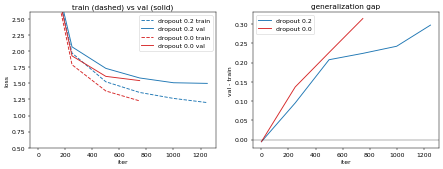

In [12]:
# Loss curves: dropout 0.2 (GPU0) vs dropout 0.0 (GPU1). Works mid-run too.
import re, matplotlib.pyplot as plt
def parse(path):
    ev = [tuple(map(float, m)) for m in re.findall(r"step (\d+): train loss ([\d.]+), val loss ([\d.]+)", open(path).read())]
    it = [tuple(map(float, m)) for m in re.findall(r"iter (\d+): loss ([\d.]+)", open(path).read())]
    return ev, it
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for path, name, c in [("train_1gpu.log", "dropout 0.2", "C0"), ("train_nodrop.log", "dropout 0.0", "C3")]:
    ev, it = parse(path)
    if not ev: continue
    s, tr, va = zip(*ev)
    ax[0].plot(s, tr, c + "--", label=f"{name} train"); ax[0].plot(s, va, c + "-", label=f"{name} val")
    ax[1].plot(s, [v - t for t, v in zip(tr, va)], c, label=name)
    print(f"{name:12s} evals={len(ev):2d}  last step {int(s[-1])}: train {tr[-1]:.4f} val {va[-1]:.4f} gap {va[-1]-tr[-1]:+.4f}  best val {min(va):.4f} @ {int(s[va.index(min(va))])}")
ax[0].set(xlabel="iter", ylabel="loss", title="train (dashed) vs val (solid)", ylim=(0.5, 2.6)); ax[0].legend()
ax[1].set(xlabel="iter", ylabel="val - train", title="generalization gap"); ax[1].axhline(0, c="k", lw=.5); ax[1].legend()
fig.set_dpi(44); fig.savefig("loss_dropout.png", dpi=120, bbox_inches="tight"); plt.show()

In [19]:
# 5. Sample from the trained model (temperature / top-k are the two knobs in sample.py)
import torch, pickle
from model import GPTConfig, GPT
def load(out_dir, dev="cuda:0"):
    ck = torch.load(f"{out_dir}/ckpt.pt", map_location=dev)
    sd = {k.removeprefix("_orig_mod."): v for k, v in ck["model"].items()}   # strip torch.compile prefix
    mdl = GPT(GPTConfig(**ck["model_args"])); mdl.load_state_dict(sd); return mdl.eval().to(dev), ck
model, ck = load("out-shakespeare-char")
print(f"checkpoint iter {ck['iter_num']}, best val loss {ck['best_val_loss']:.4f}")
enc = lambda s: torch.tensor([[stoi[c] for c in s]], device="cuda:0")
dec = lambda t: "".join(itos[i] for i in t.tolist())
torch.manual_seed(0)
for T in (0.5, 0.8, 1.2):
    out = model.generate(enc("ROMEO:\n"), max_new_tokens=250, temperature=T, top_k=200)[0]
    print(f"\n===== temperature {T} =====\n{dec(out)}")

number of parameters: 10.65M
checkpoint iter 1500, best val loss 1.4722

===== temperature 0.5 =====
ROMEO:
A grave the law thou art to be more
Than that we have mercy. I have done to be
That will be not seen to be thee and the common
Of the hand in the second of the world:
But what doth thou didst not see the trude of your crown?

Second Citizen:
What was

===== temperature 0.8 =====
ROMEO:
What abhorrow resign now? Would thou be my brother's way?

Second Citizen:
And we cannot for thy feeling pride and nature
As I say, when there he did stone of thee
Where is cries a darken to thee.

AUFIDIUS:
Come, good County and go with the great Ma

===== temperature 1.2 =====
ROMEO:
This blester'd-all in Viennet's cost it.
Ay, riddle in quest, Bohemia mother!

LEONTES:
Here come;
I'll go behind the Polixe I wish.
Her; ah, thy smother, will comfort!
I  come to you, your comfort.
I have dead!
Why should I know, Is it so? Come, Bar


manual forward matches model(): max |diff| on last-pos logits = 1.1920928955078125e-06
residual-stream norm after each block: [1.3, 15.8, 23.0, 29.8, 36.7, 44.5, 53.9]

query = last char 't'; top-3 attended positions per head (layer: head -> chars)
L0: h0:nte(0.95)  h1:ntc(1.00)  h2:nt (0.96)  h3:ent(0.97)  h4:net(0.39)  h5:etD(0.40)
L3: h0:nsc(0.55)  h1:ced(0.48)  h2:eni(0.38)  h3:onc(0.33)  h4:s o(0.82)  h5:eso(0.50)
L5: h0:sws(0.95)  h1:\n:r(0.22)  h2:inr(0.11)  h3:nui(0.24)  h4:ADG(0.18)  h5:KH (0.12)


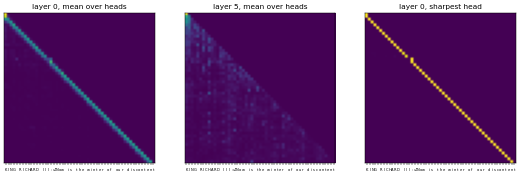

In [20]:
# 6. Open up attention: nanoGPT uses fused SDPA (no attention matrix is ever stored), so recompute it by hand
import torch.nn.functional as F, math
@torch.no_grad()
def forward_with_attn(mdl, idx):
    tr = mdl.transformer; T = idx.shape[1]
    x = tr.wte(idx) + tr.wpe(torch.arange(T, device=idx.device))
    atts, resid_norms = [], [x.norm(dim=-1).mean().item()]
    for blk in tr.h:
        a = blk.attn; h = blk.ln_1(x)
        q, k, v = a.c_attn(h).split(a.n_embd, dim=2)
        sh = lambda t: t.view(1, T, a.n_head, -1).transpose(1, 2)            # (1, nh, T, hs)
        q, k, v = sh(q), sh(k), sh(v)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(k.size(-1))
        att = att.masked_fill(torch.triu(torch.ones(T, T, device=idx.device, dtype=torch.bool), 1), float("-inf")).softmax(-1)
        atts.append(att[0])
        x = x + a.c_proj((att @ v).transpose(1, 2).reshape(1, T, -1))
        x = x + blk.mlp(blk.ln_2(x)); resid_norms.append(x.norm(dim=-1).mean().item())
    return mdl.lm_head(tr.ln_f(x)), atts, resid_norms

text = "KING RICHARD III:\nNow is the winter of our discontent"
idx = enc(text)
logits_manual, atts, norms = forward_with_attn(model, idx)
logits_ref, _ = model(idx)
print("manual forward matches model(): max |diff| on last-pos logits =", (logits_manual[0, -1] - logits_ref[0, -1]).abs().max().item())
print("residual-stream norm after each block:", [round(n, 1) for n in norms])
# what does each head look at from the LAST character?
print(f"\nquery = last char {text[-1]!r}; top-3 attended positions per head (layer: head -> chars)")
for L in (0, 3, 5):
    row = []
    for hd in range(atts[L].shape[0]):
        w, i = atts[L][hd, -1].topk(3)
        row.append(f"h{hd}:" + "".join(repr(text[j])[1:-1] for j in i.tolist()) + f"({w[0]:.2f})")
    print(f"L{L}: " + "  ".join(row))
# heatmaps for layer 0 and layer 5 (all heads averaged) + one sharp head
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for a_, (mat, ttl) in zip(ax, [(atts[0].mean(0), "layer 0, mean over heads"), (atts[5].mean(0), "layer 5, mean over heads"),
                               (atts[0][atts[0].amax(-1).mean(-1).argmax()], "layer 0, sharpest head")]):
    a_.imshow(mat.float().cpu(), cmap="viridis"); a_.set_title(ttl)
    a_.set_xticks(range(len(text))); a_.set_xticklabels([c if c != "\n" else "⏎" for c in text], fontsize=6)
    a_.set_yticks([])
fig.set_dpi(44); fig.savefig("attention.png", dpi=120, bbox_inches="tight"); plt.show()

In [24]:
# 7. Data-parallel on both T4s with torchrun (DDP). train.py splits grad-accum steps across ranks,
#    so gas=2 on 2 GPUs = 1 micro-batch per GPU, gradients all-reduced -> 2x tokens per optimizer step.
cmdD = ("torchrun --standalone --nproc_per_node=2 train.py config/train_shakespeare_char.py --dtype=float16 --compile=True "
        "--out_dir=out-ddp --gradient_accumulation_steps=2 --log_interval=50 --eval_interval=250 --max_iters=1000 --lr_decay_iters=1000")
envD = dict(os.environ, CUDA_VISIBLE_DEVICES="0,1", NCCL_P2P_DISABLE="1")   # T4s on PCIe; P2P off avoids NCCL hangs on some hosts
procD = subprocess.Popen(f"nohup {cmdD} > train_ddp.log 2>&1", shell=True, env=envD, cwd="/content/nanoGPT")
print("started pid", procD.pid); print(cmdD)

started pid 530
torchrun --standalone --nproc_per_node=2 train.py config/train_shakespeare_char.py --dtype=float16 --compile=True --out_dir=out-ddp --gradient_accumulation_steps=2 --log_interval=50 --eval_interval=250 --max_iters=1000 --lr_decay_iters=1000


In [25]:
# wait (bounded, 6 min) for the DDP run to finish, printing its eval lines
t0 = time.time()
while procD.poll() is None and time.time() - t0 < 360: time.sleep(10)
print("ddp exited:", procD.poll(), f"after {time.time()-t0:.0f}s")
print("\n".join(l for l in open("train_ddp.log").read().splitlines() if l.startswith("step") or "Error" in l))

ddp exited: 0 after 220s
step 0: train loss 4.2874, val loss 4.2823
step 250: train loss 1.7986, val loss 1.9308
step 500: train loss 1.3944, val loss 1.6190
step 750: train loss 1.2514, val loss 1.5226
step 1000: train loss 1.1903, val loss 1.4821


In [26]:
# DDP vs single-GPU throughput (tokens/sec, excluding compile + eval iterations)
def tok_per_s(path, tokens_per_iter):
    ts = [float(t) for i, t in re.findall(r"iter (\d+): loss [\d.]+, time ([\d.]+)ms", open(path).read())
          if int(i) > 0 and int(i) % 250 != 0]
    ts = sorted(ts)[: max(1, int(len(ts) * .9))]            # drop slowest 10% (eval spikes)
    return tokens_per_iter / (sum(ts) / len(ts) / 1000), sum(ts) / len(ts)
t1, ms1 = tok_per_s("train_1gpu.log", 64 * 256)
t2, ms2 = tok_per_s("train_ddp.log", 2 * 64 * 256)
print(f"1 GPU : {ms1:6.1f} ms/iter  {t1:>9,.0f} tok/s")
print(f"2 GPU : {ms2:6.1f} ms/iter  {t2:>9,.0f} tok/s   speedup {t2/t1:.2f}x  (ideal 2.00x; the gap is all-reduce of 10.7M fp32 grads over PCIe)")
print(open("train_ddp.log").read().split("\n")[-6:])

1 GPU :  110.8 ms/iter    147,890 tok/s
2 GPU :  209.8 ms/iter    156,208 tok/s   speedup 1.06x  (ideal 2.00x; the gap is all-reduce of 10.7M fp32 grads over PCIe)
['iter 900: loss 1.2821, time 347.85ms, mfu 1.98%', 'iter 950: loss 1.2757, time 114.05ms, mfu 2.10%', 'step 1000: train loss 1.1903, val loss 1.4821', 'saving checkpoint to out-ddp', 'iter 1000: loss 1.2587, time 13925.29ms, mfu 1.90%', '']


In [10]:
# probe: HuggingFace download speed (bounded to 20 s) before pulling GPT-2 weights (124M = 548 MB)
!curl -sL --max-time 20 -o /dev/null -w "downloaded %{size_download} bytes at %{speed_download} B/s\n" https://huggingface.co/openai-community/gpt2/resolve/main/model.safetensors
!pip list 2>/dev/null | grep -iE "^(transformers|tiktoken|datasets) "

downloaded 548105171 bytes at 69784844 B/s
datasets                                 5.0.0
tiktoken                                 0.12.0
transformers                             5.0.0


In [11]:
# 8. Real GPT-2 (124M) loaded into nanoGPT's own GPT class + the BPE tokenizer
import tiktoken
gpt2 = GPT.from_pretrained("gpt2", dict(dropout=0.0)).eval().to("cuda:0")
bpe = tiktoken.get_encoding("gpt2")
s = "First Citizen:\nBefore we proceed any further, hear me speak."
toks = bpe.encode(s)
print(f"\n{len(s)} chars -> {len(toks)} BPE tokens ({len(s)/len(toks):.1f} chars/token); char-level model would need {len(s)}")
print([bpe.decode([t]) for t in toks])
print("BPE vocab", bpe.n_vocab, "(pretrained keeps 50257; train.py from scratch pads to 50304 = 64*786 for faster matmuls)")
# GPT-2's loss on Shakespeare val before any finetuning, per token AND per character (comparable to the char model)
vtext = "".join(itos[i] for i in val[:20000].tolist())
vt = torch.tensor(bpe.encode(vtext), device="cuda:0")
with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
    L = [gpt2(vt[i:i+1024][None, :-1], vt[i:i+1024][None, 1:])[1].item() for i in range(0, len(vt) - 1024, 512)]
nll_tok = sum(L) / len(L)
print(f"\nGPT-2 zero-shot on shakespeare val: {nll_tok:.3f} nats/token = {nll_tok*len(vt)/len(vtext):.3f} nats/char")
torch.manual_seed(0)
out = gpt2.generate(torch.tensor([bpe.encode("ROMEO:\n")], device="cuda:0"), 80, temperature=0.8, top_k=200)
print("\n--- GPT-2 zero-shot sample ---\n" + bpe.decode(out[0].tolist()))

loading weights from pretrained gpt: gpt2
forcing vocab_size=50257, block_size=1024, bias=True
overriding dropout rate to 0.0
number of parameters: 123.65M


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


60 chars -> 14 BPE tokens (4.3 chars/token); char-level model would need 60
['First', ' Citizen', ':', '\n', 'Before', ' we', ' proceed', ' any', ' further', ',', ' hear', ' me', ' speak', '.']
vocab 50257 -> nanoGPT pads to 50257 (multiple of 64 = faster matmuls)

GPT-2 zero-shot on shakespeare val: 3.960 nats/token = 1.278 nats/char

--- GPT-2 zero-shot sample ---
ROMEO:

1. Compile and run the tool to see what's going on.

2. Remove the garbage collector.

3. Remove the ssl-backup.

4. Make sure everything is fine.

5. Save the run.bat file.

6. Open the file and see what's happening.

7. Use the command-line


In [15]:
# 9. Finetune pretrained GPT-2-medium (350M) on Shakespeare with BPE tokens (config/finetune_shakespeare.py recipe).
#    gpt2-xl (1.5B) would need ~24 GB just for fp32 weights+grads+Adam -> doesn't fit a 15 GB T4; medium needs ~6 GB.
!python data/shakespeare/prepare.py
cmdF = ("python train.py config/finetune_shakespeare.py --init_from=gpt2-medium --dtype=float16 --compile=False "
        "--out_dir=out-ft-medium --max_iters=40 --eval_interval=5 --eval_iters=20 --log_interval=1")
procF = subprocess.Popen(f"nohup {cmdF} > finetune.log 2>&1", shell=True, env=dict(os.environ, CUDA_VISIBLE_DEVICES="1"), cwd="/content/nanoGPT")
print("started pid", procF.pid); print(cmdF)
ntok = len(np.memmap('data/shakespeare/train.bin', dtype=np.uint16)) + len(np.memmap('data/shakespeare/val.bin', dtype=np.uint16))
print("chars per BPE token in shakespeare:", round(1115394 / ntok, 3))

train has 301,966 tokens
val has 36,059 tokens
started pid 493
python train.py config/finetune_shakespeare.py --init_from=gpt2-medium --dtype=float16 --compile=False --out_dir=out-ft-medium --max_iters=40 --eval_interval=5 --eval_iters=20 --log_interval=1
chars per BPE token in shakespeare: 3.3


In [22]:
# wait (bounded, 3 min) for the finetune process to exit
t0 = time.time()
while procF.poll() is None and time.time() - t0 < 180: time.sleep(5)
print("finetune exited:", procF.poll(), f"after {time.time()-t0:.0f}s")

finetune exited: 0 after 40s


In [23]:
# finetune progress + sample from the finetuned model
log = open("finetune.log").read()
print("\n".join(l for l in log.splitlines() if l.startswith(("step", "iter")))[-2500:])
if os.path.exists("out-ft-medium/ckpt.pt") and procF.poll() is not None:
    ft, ckf = load("out-ft-medium")
    print(f"\nbest val {ckf['best_val_loss']:.3f} nats/token @ iter {ckf['iter_num']}")
    torch.manual_seed(0)
    out = ft.generate(torch.tensor([bpe.encode("ROMEO:\n")], device="cuda:0"), 200, temperature=0.8, top_k=200)
    print("\n--- finetuned GPT-2-medium sample ---\n" + bpe.decode(out[0].tolist()))
    del ft; torch.cuda.empty_cache()

step 0: train loss 3.6973, val loss 3.3822
iter 0: loss 3.6564, time 8854.13ms, mfu -100.00%
iter 1: loss 2.9061, time 5933.35ms, mfu -100.00%
iter 2: loss 3.8268, time 6155.14ms, mfu -100.00%
iter 3: loss 3.5161, time 6192.38ms, mfu -100.00%
iter 4: loss 3.8158, time 6219.34ms, mfu -100.00%
step 5: train loss 3.3730, val loss 3.2079
iter 5: loss 3.1046, time 16566.16ms, mfu 1.54%
iter 6: loss 3.6036, time 6257.10ms, mfu 1.79%
iter 7: loss 3.1492, time 6295.89ms, mfu 2.02%
iter 8: loss 3.3263, time 6337.49ms, mfu 2.22%
iter 9: loss 3.0026, time 6330.96ms, mfu 2.40%
step 10: train loss 3.3784, val loss 3.1400
iter 10: loss 3.3336, time 28531.06ms, mfu 2.25%
iter 11: loss 3.1864, time 6263.93ms, mfu 2.43%
iter 12: loss 2.7303, time 6300.38ms, mfu 2.59%
iter 13: loss 2.8355, time 6317.78ms, mfu 2.73%
iter 14: loss 2.6991, time 6345.07ms, mfu 2.86%
step 15: train loss 3.3546, val loss 3.1794
iter 15: loss 3.2577, time 8867.11ms, mfu 2.86%
iter 16: loss 3.0374, time 6383.46ms, mfu 2.98%
ite

---
# Part A. Why did 2 GPUs give only 1.06×?
Controlled variants, each 300 iters, run **one at a time** so nothing else competes for the 4 vCPUs:
`1gpu` (clean baseline) · `ddp_p2poff` (original setting) · `ddp_p2pon` · `ddp_nocompile` · `1gpu_nocompile`, plus a pure NCCL all-reduce microbenchmark on the exact gradient size (10.7M fp32 = 43 MB).

In [27]:
%%writefile /content/nanoGPT/allreduce_bench.py
# all-reduce microbenchmark: how long does syncing one model's worth of gradients take between the 2 T4s?
import os, time, torch, torch.distributed as dist
dist.init_process_group("nccl"); r = dist.get_rank(); torch.cuda.set_device(r)
for numel, name in [(10_745_088, "char model grads fp32 (43 MB)"), (124_000_000, "GPT-2 124M grads fp32 (496 MB)")]:
    t = torch.randn(numel, device="cuda")
    for _ in range(3): dist.all_reduce(t)
    torch.cuda.synchronize(); t0 = time.time(); n = 10
    for _ in range(n): dist.all_reduce(t)
    torch.cuda.synchronize(); dt = (time.time() - t0) / n
    if r == 0: print(f"P2P_DISABLE={os.environ.get('NCCL_P2P_DISABLE','0')}  {name}: {dt*1000:7.1f} ms  bus bw {2*numel*4/dt/1e9:5.2f} GB/s", flush=True)
dist.destroy_process_group()

Writing /content/nanoGPT/allreduce_bench.py


In [28]:
%%writefile /content/nanoGPT/ddp_diag.sh
# run every variant sequentially; each writes diag_<name>.log
cd /content/nanoGPT
nvidia-smi topo -m > diag_topo.log 2>&1
BASE="config/train_shakespeare_char.py --dtype=float16 --max_iters=300 --lr_decay_iters=300 --eval_interval=100000 --eval_iters=1 --log_interval=10 --always_save_checkpoint=False"
NCCL_P2P_DISABLE=1 torchrun --standalone --nproc_per_node=2 allreduce_bench.py > diag_ar_p2poff.log 2>&1
torchrun --standalone --nproc_per_node=2 allreduce_bench.py > diag_ar_p2pon.log 2>&1
CUDA_VISIBLE_DEVICES=0 python train.py $BASE --compile=True  --out_dir=/tmp/d1 > diag_1gpu.log 2>&1
NCCL_P2P_DISABLE=1 torchrun --standalone --nproc_per_node=2 train.py $BASE --compile=True --gradient_accumulation_steps=2 --out_dir=/tmp/d2 > diag_ddp_p2poff.log 2>&1
NCCL_DEBUG=INFO torchrun --standalone --nproc_per_node=2 train.py $BASE --compile=True --gradient_accumulation_steps=2 --out_dir=/tmp/d3 > diag_ddp_p2pon.log 2>&1
NCCL_P2P_DISABLE=1 torchrun --standalone --nproc_per_node=2 train.py $BASE --compile=False --gradient_accumulation_steps=2 --out_dir=/tmp/d4 > diag_ddp_nocompile.log 2>&1
CUDA_VISIBLE_DEVICES=0 python train.py $BASE --compile=False --out_dir=/tmp/d5 > diag_1gpu_nocompile.log 2>&1
echo ALLDONE > diag_done.flag

Writing /content/nanoGPT/ddp_diag.sh


In [29]:
!rm -f /content/nanoGPT/diag_*.log /content/nanoGPT/diag_done.flag
procDiag = subprocess.Popen("nohup bash /content/nanoGPT/ddp_diag.sh > /content/nanoGPT/diag_driver.log 2>&1", shell=True)
print("diag started pid", procDiag.pid)

diag started pid 850


---
# Part D. Rebuild `model.py` line by line with raw tensor math
No `nn.Module`s. Every piece is written from the weights in the trained checkpoint, and each output is checked against nanoGPT's own module (`max|diff|`). Runs on CPU in fp32.

In [37]:
# D1. weights + reference model on CPU, fp32
import torch, math
ckc = torch.load("out-shakespeare-char/ckpt.pt", map_location="cpu")
W = {k.removeprefix("_orig_mod."): v.float() for k, v in ckc["model"].items()}
ref = GPT(GPTConfig(**ckc["model_args"])); ref.load_state_dict(W); ref.eval()
C = ckc["model_args"]; nL, nH, d = C["n_layer"], C["n_head"], C["n_embd"]
print(C)
for k in list(W)[:14]: print(f"{k:34s} {tuple(W[k].shape)}")
print("...", len(W), "tensors total (lm_head.weight is the SAME tensor as wte:", W["lm_head.weight"].data_ptr() == W["transformer.wte.weight"].data_ptr(), ")")
chk = lambda name, a, b: print(f"{name:34s} max|diff| = {(a - b).abs().max().item():.2e}  {'OK' if torch.allclose(a, b, atol=1e-5) else 'MISMATCH'}")
idx = torch.tensor([[stoi[c] for c in "KING RICHARD III:\nNow is the winter of our discontent"]])
T = idx.shape[1]; print("input", tuple(idx.shape))

number of parameters: 10.65M
{'n_layer': 6, 'n_head': 6, 'n_embd': 384, 'block_size': 256, 'bias': False, 'vocab_size': 65, 'dropout': 0.2}
transformer.wte.weight             (65, 384)
transformer.wpe.weight             (256, 384)
transformer.h.0.ln_1.weight        (384,)
transformer.h.0.attn.c_attn.weight (1152, 384)
transformer.h.0.attn.c_proj.weight (384, 384)
transformer.h.0.ln_2.weight        (384,)
transformer.h.0.mlp.c_fc.weight    (1536, 384)
transformer.h.0.mlp.c_proj.weight  (384, 1536)
transformer.h.1.ln_1.weight        (384,)
transformer.h.1.attn.c_attn.weight (1152, 384)
transformer.h.1.attn.c_proj.weight (384, 384)
transformer.h.1.ln_2.weight        (384,)
transformer.h.1.mlp.c_fc.weight    (1536, 384)
transformer.h.1.mlp.c_proj.weight  (384, 1536)
... 40 tensors total (lm_head.weight is the SAME tensor as wte: True )
input (1, 53)


In [38]:
# D2. embeddings: a lookup table is just row-indexing. token row + position row, added.
tok = W["transformer.wte.weight"][idx]                  # (1,T,d): row idx[t] of the 65 x 384 table
pos = W["transformer.wpe.weight"][torch.arange(T)]      # (T,d):  row t of the 256 x 384 table
x0 = tok + pos                                          # broadcast over batch
chk("embedding (wte+wpe)", x0, ref.transformer.wte(idx) + ref.transformer.wpe(torch.arange(T)))
# equivalently: one-hot @ table  (why an embedding is a linear layer with a one-hot input)
chk("one_hot @ wte == wte[idx]", torch.nn.functional.one_hot(idx, 65).float() @ W["transformer.wte.weight"], tok)

# D3. LayerNorm by hand: per position, subtract the mean over the 384 features, divide by the std, scale by a learned gain.
def layernorm(x, w, b=None, eps=1e-5):
    mu = x.mean(-1, keepdim=True)
    var = ((x - mu) ** 2).mean(-1, keepdim=True)        # BIASED variance (divide by d, not d-1), as torch does
    y = (x - mu) / torch.sqrt(var + eps) * w
    return y + b if b is not None else y                # this config has bias=False -> no b
h = layernorm(x0, W["transformer.h.0.ln_1.weight"])
chk("layernorm (block 0 ln_1)", h, ref.transformer.h[0].ln_1(x0))
g = W["transformer.h.0.ln_1.weight"]
print(f"learned gain of block0 ln_1: min {g.min():.3f} max {g.max():.3f} mean {g.mean():.3f} (init was all 1.0)")

embedding (wte+wpe)                max|diff| = 0.00e+00  OK
one_hot @ wte == wte[idx]          max|diff| = 0.00e+00  OK
layernorm (block 0 ln_1)           max|diff| = 5.96e-07  OK
learned gain of block0 ln_1: min 0.722 max 0.965 mean 0.845 (init was all 1.0)


In [39]:
# D4. causal self-attention by hand
def attention(x, p):                                     # p = "transformer.h.{i}.attn."
    B, T, d = x.shape; hs = d // nH
    qkv = x @ W[p + "c_attn.weight"].T                   # one matmul makes q,k,v together: (B,T,3d)
    q, k, v = qkv.split(d, dim=2)
    heads = lambda t: t.view(B, T, nH, hs).transpose(1, 2)            # (B,nH,T,hs): 6 independent 64-dim heads
    q, k, v = heads(q), heads(k), heads(v)
    scores = q @ k.transpose(-2, -1) / math.sqrt(hs)     # (B,nH,T,T): dot product of every query with every key
    mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)  # True above diagonal = the future
    scores = scores.masked_fill(mask, float("-inf"))     # exp(-inf) = 0 -> future tokens get zero weight
    att = scores.softmax(-1)                             # each row sums to 1
    y = att @ v                                          # weighted average of value vectors
    y = y.transpose(1, 2).contiguous().view(B, T, d)     # concatenate heads back to d=384
    return y @ W[p + "c_proj.weight"].T, att
a0, att0 = attention(h, "transformer.h.0.attn.")
chk("attention (block 0)", a0, ref.transformer.h[0].attn(h))
print("rows sum to 1:", torch.allclose(att0.sum(-1), torch.ones(1)), "| weight on future positions:", att0.triu(1).sum().item())
# why divide by sqrt(head_size)?
q_ = torch.randn(10000, 64); k_ = torch.randn(10000, 64)
print(f"for unit-variance q,k in 64 dims: var(q.k) = {(q_*k_).sum(-1).var():.1f}  -> after /sqrt(64): {((q_*k_).sum(-1)/8).var():.2f}  (keeps softmax out of its saturated, zero-gradient regime)")

# D5. MLP by hand: expand 4x, exact GELU (erf form), project back
gelu = lambda z: 0.5 * z * (1 + torch.erf(z / math.sqrt(2)))
def mlp(x, p):
    return gelu(x @ W[p + "c_fc.weight"].T) @ W[p + "c_proj.weight"].T
h2 = layernorm(x0 + a0, W["transformer.h.0.ln_2.weight"])
chk("MLP (block 0)", mlp(h2, "transformer.h.0.mlp."), ref.transformer.h[0].mlp(h2))
act = gelu(h2 @ W["transformer.h.0.mlp.c_fc.weight"].T)
print(f"MLP hidden (1536 units): {(act > 0.01).float().mean():.1%} of units clearly active per position")

attention (block 0)                max|diff| = 1.49e-07  OK
rows sum to 1: True | weight on future positions: 0.0
for unit-variance q,k in 64 dims: var(q.k) = 64.5  -> after /sqrt(64): 1.01  (keeps softmax out of its saturated, zero-gradient regime)
MLP (block 0)                      max|diff| = 1.91e-06  OK
MLP hidden (1536 units): 13.4% of units clearly active per position


In [34]:
# Part A results: ms/iter per variant (median of iters >= 50, compile warmup excluded) + all-reduce bench
import glob, statistics
t0 = time.time()
while not os.path.exists("diag_done.flag") and time.time() - t0 < 400: time.sleep(10)   # bounded wait
def med_ms(path):
    ts = [float(t) for i, t in re.findall(r"iter (\d+): loss [\d.]+, time ([\d.]+)ms", open(path).read()) if int(i) >= 50]
    return statistics.median(ts) if ts else None
print("done flag:", os.path.exists("diag_done.flag"))
for f in ["diag_ar_p2poff.log", "diag_ar_p2pon.log"]:
    if os.path.exists(f): print("\n".join(l for l in open(f).read().splitlines() if l.startswith("P2P")))
rows = [("1gpu", 1), ("ddp_p2poff", 2), ("ddp_p2pon", 2), ("1gpu_nocompile", 1), ("ddp_nocompile", 2)]
res = {}
for name, ngpu in rows:
    f = f"diag_{name}.log"
    if not os.path.exists(f) or med_ms(f) is None: print(f"{name:16s} (not finished)"); continue
    ms = med_ms(f); res[name] = ngpu * 64 * 256 / (ms / 1000)
    print(f"{name:16s} {ms:7.1f} ms/iter  {res[name]:>9,.0f} tok/s")
if "ddp_p2poff" in res: print(f"\nDDP speedup, compiled: {res['ddp_p2poff']/res['1gpu']:.2f}x (P2P off)  {res['ddp_p2pon']/res['1gpu']:.2f}x (P2P on)")
if "ddp_nocompile" in res: print(f"DDP speedup, eager   : {res['ddp_nocompile']/res['1gpu_nocompile']:.2f}x   | torch.compile gain on 1 GPU: {res['1gpu']/res['1gpu_nocompile']:.2f}x")
if os.path.exists("diag_ddp_p2pon.log"):
    print("NCCL transport chosen with P2P allowed:", sorted(set(re.findall(r"via (\S+)", open("diag_ddp_p2pon.log").read()))))
print("GPU0<->GPU1 topology:", [l for l in open("diag_topo.log").read().splitlines() if l.startswith("GPU0")][0].split("\t")[:3])

done flag: True
P2P_DISABLE=1  char model grads fp32 (43 MB):    10.8 ms  bus bw  7.96 GB/s
P2P_DISABLE=1  GPT-2 124M grads fp32 (496 MB):   122.7 ms  bus bw  8.08 GB/s
P2P_DISABLE=0  char model grads fp32 (43 MB):    10.8 ms  bus bw  7.96 GB/s
P2P_DISABLE=0  GPT-2 124M grads fp32 (496 MB):   123.0 ms  bus bw  8.06 GB/s
1gpu               103.3 ms/iter    158,644 tok/s
ddp_p2poff         118.4 ms/iter    276,827 tok/s
ddp_p2pon          119.1 ms/iter    275,153 tok/s
1gpu_nocompile     128.5 ms/iter    127,542 tok/s
ddp_nocompile      130.1 ms/iter    251,955 tok/s

DDP speedup, compiled: 1.74x (P2P off)  1.73x (P2P on)
DDP speedup, eager   : 1.98x   | torch.compile gain on 1 GPU: 1.24x
NCCL transport chosen with P2P allowed: ['SHM/direct/direct', 'command']
GPU0<->GPU1 topology: ['GPU0', ' X ', 'PHB']


In [32]:
# forensic: per-iteration times of the ORIGINAL slow DDP run vs the clean re-run
orig = [(int(i), float(t)) for i, t in re.findall(r"iter (\d+): loss [\d.]+, time ([\d.]+)ms", open("train_ddp.log").read())]
print("original DDP run, iter:ms ->", " ".join(f"{i}:{t:.0f}" for i, t in orig))
for name in ["ddp_p2poff", "1gpu"]:
    it = dict((int(i), float(t)) for i, t in re.findall(r"iter (\d+): loss [\d.]+, time ([\d.]+)ms", open(f"diag_{name}.log").read()))
    hund = [it[i] for i in (100, 200, 300) if i in it]; other = [t for i, t in it.items() if i >= 50 and i % 100]
    print(f"\n{name:11s} iters that are multiples of 100: {[round(t) for t in hund]} ms | all other iters: median {statistics.median(other):.0f} ms")

original DDP run, iter:ms -> 0:46403 50:106 100:327 150:110 200:337 250:13623 300:351 350:115 400:345 450:110 500:13496 550:112 600:339 650:112 700:348 750:13890 800:352 850:115 900:348 950:114 1000:13925

ddp_p2poff  iters that are multiples of 100: [347, 365, 370] ms | all other iters: median 117 ms

1gpu        iters that are multiples of 100: [102, 103, 112] ms | all other iters: median 103 ms


In [40]:
# D6. the whole GPT forward, cross-entropy loss, and generation, all by hand
def block(x, i):
    p = f"transformer.h.{i}."
    x = x + attention(layernorm(x, W[p + "ln_1.weight"]), p + "attn.")[0]   # pre-norm residual: x += f(LN(x))
    x = x + mlp(layernorm(x, W[p + "ln_2.weight"]), p + "mlp.")
    return x
def gpt(idx):
    T = idx.shape[1]
    x = W["transformer.wte.weight"][idx] + W["transformer.wpe.weight"][:T]
    for i in range(nL): x = block(x, i)
    x = layernorm(x, W["transformer.ln_f.weight"])
    return x @ W["transformer.wte.weight"].T            # weight tying: the output projection IS the embedding table
tgt = torch.roll(idx, -1, 1)
logits_ref, loss_ref = ref(idx, tgt)                   # passing targets makes nanoGPT return logits for ALL positions
logits_me = gpt(idx)
chk("full forward logits", logits_me, logits_ref)
# cross-entropy = mean over positions of -log softmax(logits)[correct token]
logp = logits_me - logits_me.logsumexp(-1, keepdim=True)
loss_me = -logp.gather(-1, tgt[..., None]).mean()
chk("cross-entropy loss", loss_me, loss_ref)
print(f"loss {loss_me.item():.4f} nats/char -> perplexity {loss_me.exp().item():.2f} (the model is as unsure as a uniform pick among ~{loss_me.exp().item():.0f} chars)")

@torch.no_grad()
def generate(idx, n, temperature=0.8, top_k=200, g=None):
    for _ in range(n):
        lg = gpt(idx[:, -C["block_size"]:])[:, -1] / temperature     # only the last position's prediction is used
        if top_k is not None:
            v, _ = torch.topk(lg, min(top_k, lg.size(-1)))
            lg[lg < v[:, [-1]]] = -float("inf")
        idx = torch.cat([idx, torch.multinomial(lg.softmax(-1), 1, generator=g)], 1)
    return idx
prompt = torch.tensor([[stoi[c] for c in "ROMEO:\n"]])
torch.manual_seed(42); mine = generate(prompt, 60)
torch.manual_seed(42); theirs = ref.generate(prompt, 60, temperature=0.8, top_k=200)
print("hand-written generate == nanoGPT generate (same seed):", torch.equal(mine, theirs))
print(repr(dec(mine[0])))

full forward logits                max|diff| = 5.72e-06  OK
cross-entropy loss                 max|diff| = 0.00e+00  OK
loss 0.9516 nats/char -> perplexity 2.59 (the model is as unsure as a uniform pick among ~3 chars)
hand-written generate == nanoGPT generate (same seed): True
'ROMEO:\nMy lord, shall we die in his deed?\n\nLUCIO:\nBe no other to th'


---
# Parts B + C. Ablations and a scaling sweep (job queue, one run per GPU)
`ablate.py` patches `model.py` in memory (via env var `ABLATE`), then runs the unmodified `train.py`. Every run uses the same settings: shakespeare_char, dropout 0.2, 2000 iters, eval every 250, seed 1337. **Metric = best val loss** (the model overfits after ~1500 iters, so the final loss would mislead).
- **Ablations** of the 6L/6H/384 baseline: `nopos` (position embedding zeroed + frozen), `heads1`, `heads12`, `noln` (every LayerNorm → identity), `untied` (separate output matrix), `nomlp` (attention only)
- **Scaling**: (layers, width) = (1,64) (2,128) (3,192) (4,256) (6,384) (8,512)

In [35]:
%%writefile /content/nanoGPT/ablate.py
# usage: ABLATE=nopos python ablate.py config/... --key=val   (patches model.py, then runs the real train.py)
import os, sys, runpy, torch, torch.nn as nn
import model
mode = os.environ.get("ABLATE", "none")
_init = model.GPT.__init__
def patched_init(self, config):
    _init(self, config)
    if mode == "nopos":                       # no position information at all (except what causal masking leaks)
        nn.init.zeros_(self.transformer.wpe.weight); self.transformer.wpe.weight.requires_grad_(False)
    if mode == "untied":                      # output projection gets its own matrix
        self.lm_head.weight = nn.Parameter(self.transformer.wte.weight.detach().clone())
    if mode == "nomlp":                       # attention-only transformer
        for b in self.transformer.h: b.mlp = ZeroMLP()
    print(f"[ablate] mode={mode}  trainable params={sum(p.numel() for p in self.parameters() if p.requires_grad):,}", flush=True)
class ZeroMLP(nn.Module):
    def forward(self, x): return torch.zeros_like(x)
model.GPT.__init__ = patched_init
if mode == "noln":
    model.LayerNorm.forward = lambda self, x: x
sys.argv = ["train.py"] + sys.argv[1:]
runpy.run_path("train.py", run_name="__main__")

Writing /content/nanoGPT/ablate.py


In [36]:
# job queue: 2 worker threads, each owns one GPU and pulls the next job when its current one exits
import threading, queue, json
COMMON = ("config/train_shakespeare_char.py --dtype=float16 --compile=True --max_iters=2000 --lr_decay_iters=2000 "
          "--eval_interval=250 --eval_iters=100 --log_interval=50 --always_save_checkpoint=False")
JOBS = [  # (name, ABLATE mode, extra args); biggest job first so it doesn't finish last alone
    ("s8x512",  "none", "--n_layer=8 --n_head=8 --n_embd=512"),
    ("base",    "none",   ""), ("nopos", "nopos", ""), ("heads1", "none", "--n_head=1"), ("heads12", "none", "--n_head=12"),
    ("noln",    "noln",   ""), ("untied", "untied", ""), ("nomlp", "nomlp", ""),
    ("s1x64",   "none", "--n_layer=1 --n_head=2 --n_embd=64"),  ("s2x128", "none", "--n_layer=2 --n_head=2 --n_embd=128"),
    ("s3x192",  "none", "--n_layer=3 --n_head=3 --n_embd=192"), ("s4x256", "none", "--n_layer=4 --n_head=4 --n_embd=256"),
]   # the 6x384 scaling point is "base"
jq = queue.Queue(); [jq.put(j) for j in JOBS]
status = {}
def worker(gpu):
    while True:
        try: name, mode, extra = jq.get_nowait()
        except queue.Empty: return
        status[name] = f"running on GPU{gpu}"
        env = dict(os.environ, CUDA_VISIBLE_DEVICES=str(gpu), ABLATE=mode)
        c = f"python ablate.py {COMMON} --out_dir=/tmp/abl_{name} {extra} > abl_{name}.log 2>&1"
        rc = subprocess.run(c, shell=True, env=env, cwd="/content/nanoGPT").returncode
        status[name] = f"done rc={rc}"
workers = []
for g in (0, 1):
    t = threading.Thread(target=worker, args=(g,), daemon=True); t.start(); workers.append(t)
print(len(JOBS), "jobs queued, 2 workers started")

12 jobs queued, 2 workers started


In [45]:
# queue status: best val per finished/running job
def summary(name):
    f = f"abl_{name}.log"
    if not os.path.exists(f): return None
    s = open(f).read()
    ev = [tuple(map(float, m)) for m in re.findall(r"step (\d+): train loss ([\d.]+), val loss ([\d.]+)", s)]
    npar = re.search(r"trainable params=([\d,]+)", s)          # printed AFTER the ablation patch (nanoGPT's own count is pre-patch)
    err = "Traceback" in s
    if not ev: return dict(name=name, err=err)
    best = min(ev, key=lambda e: e[2])
    return dict(name=name, params_M=int(npar.group(1).replace(",", "")) / 1e6 if npar else None, last_step=int(ev[-1][0]),
                best_val=best[2], best_step=int(best[0]), train_at_best=best[1], err=err)
for n, *_ in JOBS:
    r = summary(n); st = status.get(n, "queued")
    if r and "best_val" in r:
        print(f"{n:8s} {st:18s} params {r['params_M']:6.2f}M  step {r['last_step']:5d}  best val {r['best_val']:.4f} @ {r['best_step']:4d} (train {r['train_at_best']:.3f})" + ("  ERROR" if r['err'] else ""))
    else: print(f"{n:8s} {st}" + ("  ERROR (see log)" if r and r.get('err') else ""))

s8x512   done rc=0          params  25.34M  step  2000  best val 1.4782 @ 1250 (train 1.088)
base     done rc=0          params  10.75M  step  2000  best val 1.4491 @ 2000 (train 1.071)
nopos    done rc=0          params  10.65M  step  2000  best val 1.5703 @ 2000 (train 1.282)
heads1   done rc=0          params  10.75M  step  2000  best val 1.4879 @ 2000 (train 1.187)
heads12  done rc=0          params  10.75M  step  2000  best val 1.4592 @ 1500 (train 1.114)
noln     done rc=0          params  10.75M  step  2000  best val 1.5795 @ 2000 (train 1.357)
untied   done rc=0          params  10.77M  step  2000  best val 1.4586 @ 2000 (train 1.076)
nomlp    done rc=0          params   3.67M  step  2000  best val 1.8226 @ 2000 (train 1.640)
s1x64    done rc=0          params   0.07M  step  2000  best val 2.3455 @ 2000 (train 2.311)
s2x128   done rc=0          params   0.43M  step  2000  best val 1.9623 @ 2000 (train 1.805)
s3x192   done rc=0          params   1.39M  step  2000  best val 1.625

ablation   best val  Δ vs base  @step   params
base         1.4491    +0.0000   2000   10.75M
nopos        1.5703    +0.1212   2000   10.65M
heads1       1.4879    +0.0388   2000   10.75M
heads12      1.4592    +0.0101   1500   10.75M
noln         1.5795    +0.1304   2000   10.75M
untied       1.4586    +0.0095   2000   10.77M
nomlp        1.8226    +0.3735   2000    3.67M

size       non-emb N  best val train@best best step
s1x64         49,152    2.3455     2.3111      2000
s2x128       393,216    1.9623     1.8053      2000
s3x192     1,327,104    1.6258     1.4229      2000
s4x256     3,145,728    1.5119     1.2698      2000
base      10,616,832    1.4491     1.0714      2000
s8x512    25,165,824    1.4782     1.0876      1250

log-log slope of val loss vs N over the 4 smallest models: -0.109  (Kaplan 2020 found ~ -0.076 for LLM-scale web text)


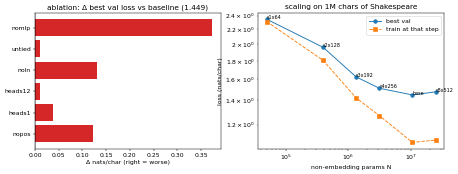

In [46]:
# Parts B + C results: ablation deltas vs baseline + scaling curve (best val vs non-embedding params, log-log)
R = {n: summary(n) for n, *_ in JOBS}
b = R["base"]["best_val"]
print(f"{'ablation':9s} {'best val':>9s} {'Δ vs base':>10s} {'@step':>6s} {'params':>8s}")
for n in ["base", "nopos", "heads1", "heads12", "noln", "untied", "nomlp"]:
    r = R[n]; print(f"{n:9s} {r['best_val']:9.4f} {r['best_val']-b:+10.4f} {r['best_step']:6d} {r['params_M']:7.2f}M")
sc = [("s1x64", 1, 64), ("s2x128", 2, 128), ("s3x192", 3, 192), ("s4x256", 4, 256), ("base", 6, 384), ("s8x512", 8, 512)]
N = [12 * L * w * w for _, L, w in sc]                       # non-embedding params (Kaplan et al. convention)
Lv = [R[n]["best_val"] for n, *_ in sc]; Lt = [R[n]["train_at_best"] for n, *_ in sc]
print(f"\n{'size':8s} {'non-emb N':>11s} {'best val':>9s} {'train@best':>10s} {'best step':>9s}")
for (n, L_, w), n_, v, t in zip(sc, N, Lv, Lt): print(f"{n:8s} {n_:>11,} {v:9.4f} {t:10.4f} {R[n]['best_step']:9d}")
slope = np.polyfit(np.log(N[:4]), np.log(Lv[:4]), 1)[0]
print(f"\nlog-log slope of val loss vs N over the 4 smallest models: {slope:.3f}  (Kaplan 2020 found ~ -0.076 for LLM-scale web text)")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
names = ["nopos", "heads1", "heads12", "noln", "untied", "nomlp"]
ax[0].barh(names, [R[n]["best_val"] - b for n in names], color=["C3" if R[n]["best_val"] > b else "C2" for n in names])
ax[0].axvline(0, c="k", lw=.8); ax[0].set(title=f"ablation: Δ best val loss vs baseline ({b:.3f})", xlabel="Δ nats/char (right = worse)")
ax[1].loglog(N, Lv, "o-", label="best val"); ax[1].loglog(N, Lt, "s--", label="train at that step")
for (n, *_), x_, y_ in zip(sc, N, Lv): ax[1].annotate(n, (x_, y_), fontsize=8)
ax[1].set(title="scaling on 1M chars of Shakespeare", xlabel="non-embedding params N", ylabel="loss (nats/char)"); ax[1].legend()
fig.set_dpi(44); fig.savefig("ablation_scaling.png", dpi=120, bbox_inches="tight"); plt.show()

In [41]:
# D7. two details in model.py that are easy to skip: the parameter-count formula and the scaled residual init
V, Tmax = C["vocab_size"], C["block_size"]
formula = nL * 12 * d * d + V * d + Tmax * d + (2 * nL + 1) * d      # per block: 3d^2 (qkv) + d^2 (proj) + 8d^2 (mlp) = 12 d^2
print(f"params by formula {formula:,}  vs  counted {sum(p.numel() for p in ref.parameters()):,}   (blocks = {nL*12*d*d/formula:.1%} of the model)")

# model.py initializes every c_proj (the layers that WRITE into the residual stream) with std 0.02/sqrt(2*n_layer).
# Why: each block adds 2 terms to x. With plain std 0.02, the residual's variance grows with depth.
@torch.no_grad()
def resid_growth(scaled, L=24, reps=3):
    out = []
    for s in range(reps):
        torch.manual_seed(s)
        m_ = GPT(GPTConfig(n_layer=L, n_head=6, n_embd=384, block_size=256, vocab_size=65, bias=False, dropout=0.0))
        if not scaled:                                   # undo the special init
            for n_, p_ in m_.named_parameters():
                if n_.endswith("c_proj.weight"): torch.nn.init.normal_(p_, 0.0, 0.02)
        x = m_.transformer.wte(idx) + m_.transformer.wpe(torch.arange(T)); norms = [x.std().item()]
        for b in m_.transformer.h: x = b(x); norms.append(x.std().item())
        out.append(norms)
    return torch.tensor(out).mean(0)
g_s, g_u = resid_growth(True), resid_growth(False)
print("residual std after block 0, 6, 12, 18, 24 (24-layer net at init):")
print("  scaled init 0.02/sqrt(2L):", [round(g_s[i].item(), 4) for i in (0, 6, 12, 18, 24)])
print("  plain  init 0.02        :", [round(g_u[i].item(), 4) for i in (0, 6, 12, 18, 24)])

params by formula 10,745,088  vs  counted 10,745,088   (blocks = 98.8% of the model)
number of parameters: 42.51M
number of parameters: 42.51M
number of parameters: 42.51M
number of parameters: 42.51M
number of parameters: 42.51M
number of parameters: 42.51M
residual std after block 0, 6, 12, 18, 24 (24-layer net at init):
  scaled init 0.02/sqrt(2L): [0.0284, 0.0719, 0.0997, 0.1231, 0.1431]
  plain  init 0.02        : [0.0284, 0.5233, 0.7467, 0.9156, 1.0438]
